# Pruning :

 technique used to simplify the model by removing unnecessary branches and nodes that do not significantly contribute to predictive performance

types : pre pruning and post pruning .

In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions



In [15]:
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [16]:
x  =dataset.iloc[:,[2,3]]
y = dataset.iloc[:,4]

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

In [18]:
from sklearn.tree import DecisionTreeClassifier


# Pre Pruning : 

In [19]:
dt = DecisionTreeClassifier(max_depth=5) # max depth function used for pre Pruning 
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [20]:
print("Acurracy after pre pruning : ",dt.score(x_test,y_test)) # Accuracy score increased

Acurracy after pre pruning :  0.95


In [21]:
dt.score(x_train,y_train)

0.9433333333333334

# Post Pruning :

  max depth function used for pre Pruning , then we check for many values and where the accuracy fits best we use that value.

In [22]:
for i in range(1,20):
    dt2 = DecisionTreeClassifier(max_depth=i)
    dt2.fit(x_train,y_train)

    print("Training data accuracy : ",dt2.score(x_train,y_train)*100,i) , print("Testing Data Accuracy : ",dt2.score(x_test,y_test)*100 ,i)

Training data accuracy :  82.0 1
Testing Data Accuracy :  89.0 1
Training data accuracy :  91.0 2
Testing Data Accuracy :  94.0 2
Training data accuracy :  91.66666666666666 3
Testing Data Accuracy :  94.0 3
Training data accuracy :  93.33333333333333 4
Testing Data Accuracy :  93.0 4
Training data accuracy :  94.33333333333334 5
Testing Data Accuracy :  95.0 5
Training data accuracy :  95.33333333333334 6
Testing Data Accuracy :  94.0 6
Training data accuracy :  96.0 7
Testing Data Accuracy :  93.0 7
Training data accuracy :  97.33333333333334 8
Testing Data Accuracy :  92.0 8
Training data accuracy :  97.66666666666667 9
Testing Data Accuracy :  92.0 9
Training data accuracy :  99.0 10
Testing Data Accuracy :  93.0 10
Training data accuracy :  99.66666666666667 11
Testing Data Accuracy :  91.0 11
Training data accuracy :  99.66666666666667 12
Testing Data Accuracy :  91.0 12
Training data accuracy :  100.0 13
Testing Data Accuracy :  90.0 13
Training data accuracy :  100.0 14
Testing

Based on above Accuracy Difference use value of max depth for training data :


In [25]:
dt3 = DecisionTreeClassifier(max_depth=6)
dt3.fit(x_train,y_train)

dt3.score(x_train,y_train)

0.9533333333333334

/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


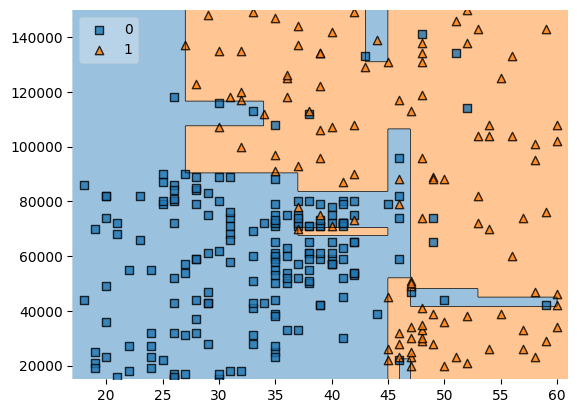

In [26]:
plot_decision_regions(x_train.to_numpy(),y_train.to_numpy(),clf=dt3,legend=2)
plt.show()

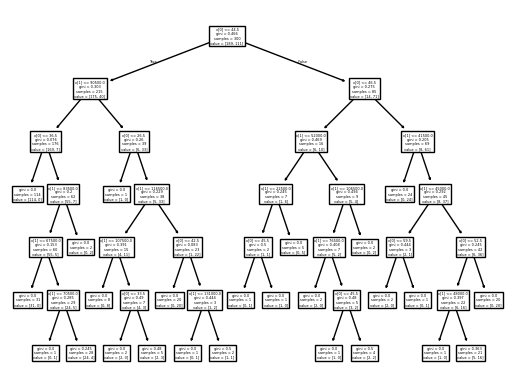

In [27]:
from sklearn.tree import plot_tree
plot_tree(dt3)
plt.show()